In [ ]:
import os
import cv2
import matplotlib.pyplot as plt



# Reading the Dataset

In [ ]:
import glob

dataset_path = "/content/drive/MyDrive/Birds"

files = glob.glob(dataset_path + "/*.jpg")

print("Number of .jpg images:", len(files))

Number of .jpg images: 187


#Display Some Outputs

In [ ]:


plt.figure(figsize=(12,5))

for i in range(10):
    img = cv2.imread(files[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

#Display the Histogram

In [ ]:


img = cv2.imread(files[0], 0)   # change 0 to any index you want

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Selected Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.hist(img.ravel(), bins=256)
plt.title("Histogram")

plt.tight_layout()
plt.show()

# Adding Salt & Pepper Noises

In [ ]:
import numpy as np

img = cv2.imread(files[0], 0)   # change index if needed

noisy = img.copy()

num_salt = 1000
x = np.random.randint(0, img.shape[0], num_salt)
y = np.random.randint(0, img.shape[1], num_salt)
noisy[x, y] = 255

num_pepper = 1000
x = np.random.randint(0, img.shape[0], num_pepper)
y = np.random.randint(0, img.shape[1], num_pepper)
noisy[x, y] = 0

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(noisy, cmap="gray")
plt.title("Salt and Pepper Noise")
plt.axis("off")

plt.tight_layout()
plt.show()

# Whole Datast

In [ ]:


noisy_images = []

for file in files:
    img = cv2.imread(file, 0)

    noisy = img.copy()

    num_salt = 1000
    x = np.random.randint(0, img.shape[0], num_salt)
    y = np.random.randint(0, img.shape[1], num_salt)
    noisy[x, y] = 255

    num_pepper = 1000
    x = np.random.randint(0, img.shape[0], num_pepper)
    y = np.random.randint(0, img.shape[1], num_pepper)
    noisy[x, y] = 0

    noisy_images.append(noisy)

print("Total noisy images:", len(noisy_images))

# Gussian Noise Reduction

In [ ]:
img = cv2.imread(files[0], 0)   # change index if needed

blur = cv2.GaussianBlur(img, (5,5), 0)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")

# Whole Dataset

In [ ]:
import cv2

blurred_images = []

for file in files:
    img = cv2.imread(file, 0)
    blur = cv2.GaussianBlur(img, (5,5), 0)
    blurred_images.append(blur)

print("Total blurred images:", len(blurred_images))

#Sobel & Laplacian Operators

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(files[0], 0)   # change index if needed

sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
laplacian = cv2.Laplacian(img, cv2.CV_64F)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(sobel_x, cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(sobel_y, cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(laplacian, cmap="gray")
plt.title("Laplacian")
plt.axis("off")

plt.tight_layout()
plt.show()

# Prewitt & Canny Operators

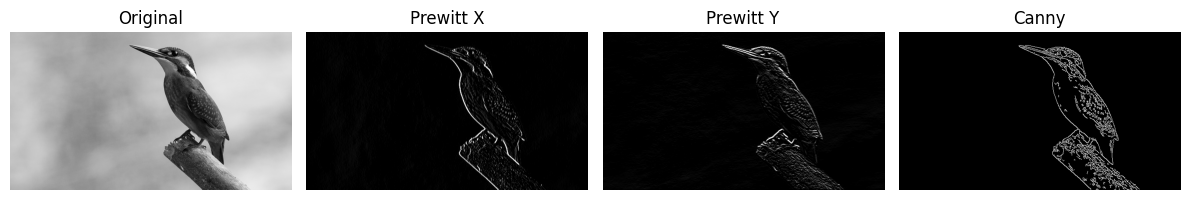

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread(files[0], 0)   # change index if needed

kernel_x = np.array([[1, 0, -1],
                     [1, 0, -1],
                     [1, 0, -1]])

kernel_y = np.array([[1, 1, 1],
                     [0, 0, 0],
                     [-1, -1, -1]])

prewitt_x = cv2.filter2D(img, -1, kernel_x)
prewitt_y = cv2.filter2D(img, -1, kernel_y)
canny = cv2.Canny(img, 100, 200)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(prewitt_x, cmap="gray")
plt.title("Prewitt X")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(prewitt_y, cmap="gray")
plt.title("Prewitt Y")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(canny, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.tight_layout()
plt.show()